# 1D CDW Hartree SCF: Nearest-Neighbor and Long-Range Interactions

This notebook compares two Hartree builders in the SCF module. The nearest-neighbor example uses non-cyclic shift MPOs to construct a sparse fixed-distance interaction. The long-range example compresses a dense interaction kernel `V(i,j)` by interleaved QTCI and then contracts it with the density profile.

In [2]:
using LinearAlgebra
using Plots
using ITensors
using ITensorMPS

include("../src/TensorBinding.jl")
using .TensorBinding





## 1. Non-interacting chain

We use a small spinless chain so the notebook runs quickly. The physical site count is `H0.N = 2^L`.

In [3]:
L = 4
N = 2^L
t = 1.0
Nel = div(N, 2)

H0 = TensorBinding.get_Hamiltonian("chain_1d", t; L=L, scale=4.0)
println(H0)

TBHamiltonian | L=4, N=16, scale=4.0, maxlinkdim=3 | geometry: 16 sites, 1D | no Tn cache


## 2. Alternating CDW initial density

A small staggered seed selects a CDW branch while keeping the average filling near half filling.

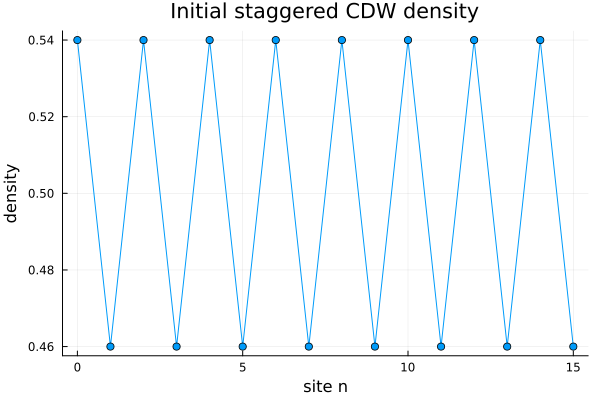

In [4]:
seed = 0.04
rho0 = TensorBinding.scf_profile_mps(
    H0.L,
    H0.sites,
    n -> 0.5 + seed * (-1)^n;
    type=Float64,
    tol=1e-10,
)

rho0_vals = [TensorBinding.scf_eval_profile_mps(rho0, n) for n in 0:H0.N-1]

plot(0:H0.N-1, rho0_vals;
     marker=:circle,
     xlabel="site n",
     ylabel="density",
     title="Initial staggered CDW density",
     legend=false)

## 3. Nearest-neighbor interaction CDW

For a fixed-distance density-density interaction, the SCF module builds the interaction MPO from two non-cyclic shift MPOs. For nearest neighbors this represents

`V(i,j) = V1` if `|i-j| = 1`, otherwise `0`, with no boundary wrap.

In [5]:
V1 = 3.0

nn_builder = TensorBinding.scf_pair_distance_hartree_builder(
    H0.L,
    H0.sites,
    1,
    V1;
    background=0.5,
    maxdim=80,
    cutoff=1e-8,
)

#459 (generic function with 1 method)

In [6]:
result_nn = TensorBinding.scf_meanfield(
    H0,
    nn_builder;
    initial_density=rho0,
    density_method=:mcweeny,
    Nel=Nel,
    scale=5,
    max_scf_iter=35,
    purif_maxiter=30,
    purif_tol=1e-5,
    scf_tol=1e-3,
    mix=0.45,
    maxdim=80,
    cutoff=1e-8,
    verbose=true,
)

println("NN converged = ", result_nn.converged)
println("NN iterations = ", result_nn.iterations)
println("NN final RMS = ", result_nn.rms_error)

┌ Warning: Calling `inner(x::MPS, A::MPO, y::MPS)` where the site indices of the `MPS`
│ `x` and the `MPS` resulting from contracting `MPO` `A` with `MPS` `y` don't
│ match is deprecated as of ITensors v0.3 and will result in an error in ITensors
│ v0.4. The most common cause of this is something like the following:
│ 
│ ```julia
│ s = siteinds("S=1/2")
│ psi = random_mps(s)
│ H = MPO(s, "Id")
│ inner(psi, H, psi)
│ ```
│ 
│ `psi` has the Index structure `-s-(psi)` and `H` has the Index structure
│ `-s'-(H)-s-`, so the Index structure of would be `(dag(psi)-s- -s'-(H)-s-(psi)`
│  unless the prime levels were fixed. Previously we tried fixing the prime level
│   in situations like this, but we will no longer be doing that going forward.
│ 
│ There are a few ways to fix this. You can simply change:
│ 
│ ```julia
│ inner(psi, H, psi)
│ ```
│ 
│ to:
│ 
│ ```julia
│ inner(psi', H, psi)
│ ```
│ 
│ in which case the Index structure will be `(dag(psi)-s'-(H)-s-(psi)`.
│ 
│ Alternatively, you c

SCF iter=1 rms=0.09230875643183949 particle_err=1.5904863541749137e-6
SCF iter=2 rms=0.12900420065921667 particle_err=1.5851485075657479e-6
SCF iter=3 rms=0.14991254017413738 particle_err=3.5566402356579374e-7
SCF iter=4 rms=0.1438355760963569 particle_err=1.7260394562512715e-6
SCF iter=5 rms=0.1185719614196965 particle_err=8.619282025890129e-7
SCF iter=6 rms=0.08823085909199793 particle_err=1.1764281708792623e-6
SCF iter=7 rms=0.06164904621509083 particle_err=1.4618410899558398e-6
SCF iter=8 rms=0.04160027466171925 particle_err=2.45464267845108e-6
SCF iter=9 rms=0.027542960107826864 particle_err=2.872981344381742e-6
SCF iter=10 rms=0.01794919670497123 particle_err=2.4194713708070026e-6
SCF iter=11 rms=0.011656039856988857 particle_err=5.645620815286634e-7
SCF iter=12 rms=0.007512072417538852 particle_err=2.807201191501463e-7
SCF iter=13 rms=0.004808122482578743 particle_err=3.139455539979963e-7
SCF iter=14 rms=0.003085058135795673 particle_err=7.506986818839323e-7
SCF iter=15 rms=0.00

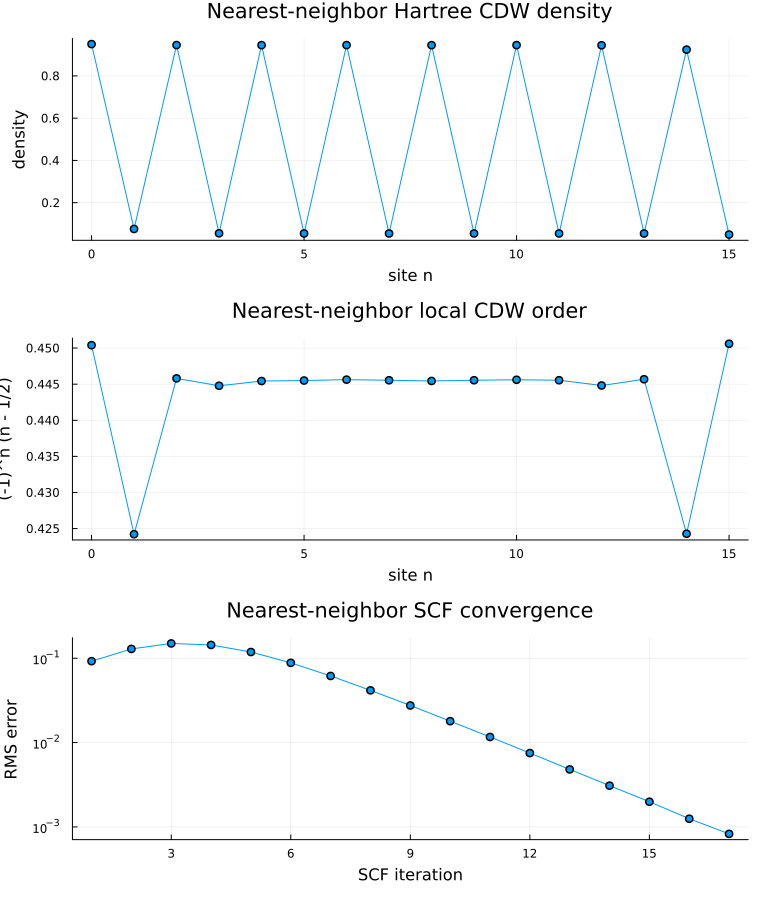

In [7]:
rho_nn = [TensorBinding.scf_eval_profile_mps(result_nn.density_mps, n) for n in 0:H0.N-1]
cdw_nn = [(-1)^n * (rho_nn[n + 1] - 0.5) for n in 0:H0.N-1]
hist_nn_iter = [h.iter for h in result_nn.history]
hist_nn_rms = [h.rms_error for h in result_nn.history]

p1 = plot(0:H0.N-1, rho_nn;
          marker=:circle,
          xlabel="site n",
          ylabel="density",
          title="Nearest-neighbor Hartree CDW density",
          legend=false)

p2 = plot(0:H0.N-1, cdw_nn;
          marker=:circle,
          xlabel="site n",
          ylabel="(-1)^n (n - 1/2)",
          title="Nearest-neighbor local CDW order",
          legend=false)

p3 = plot(hist_nn_iter, hist_nn_rms;
          yscale=:log10,
          marker=:circle,
          xlabel="SCF iteration",
          ylabel="RMS error",
          title="Nearest-neighbor SCF convergence",
          legend=false)

plot(p1, p2, p3; layout=(3, 1), size=(760, 900))

## 4. Dense long-range interaction CDW

Now we switch to a dense screened Coulomb-like kernel. The onsite self-interaction is removed, and the distance is open-boundary for this simple chain.

This is a compact example for the dense long-range SCF algorithm because the kernel is not just a few diagonals: the interaction operator is learned as a compressed MPO, then reused in every SCF iteration.

In [8]:
V0 = 2
softening = 0.7
screening = 3.0

function V_long(i, j)
    i == j && return 0.0
    r = abs(i - j)
    return V0 * exp(-r / screening) / sqrt(r^2 + softening^2)
end

long_builder = TensorBinding.scf_dense_hartree_builder(
    V_long,
    H0.L,
    H0.sites;
    background=0.5,
    tol=1e-8,
    maxdim=90,
    cutoff=1e-8,
)

#451 (generic function with 1 method)

In [9]:
result_long = TensorBinding.scf_meanfield(
    H0,
    long_builder;
    initial_density=rho0,
    density_method=:mcweeny,
    Nel=Nel,
    scale=5.5,
    max_scf_iter=40,
    purif_maxiter=30,
    purif_tol=1e-5,
    scf_tol=1e-3,
    mix=0.25,
    maxdim=90,
    cutoff=1e-8,
    verbose=true,
)

println("long-range converged = ", result_long.converged)
println("long-range iterations = ", result_long.iterations)
println("long-range final RMS = ", result_long.rms_error)

SCF iter=1 rms=0.01057573568273027 particle_err=1.3169250481226413e-6
SCF iter=2 rms=0.007007298692919891 particle_err=2.0784057745970586e-6
SCF iter=3 rms=0.004629260215812456 particle_err=1.110801209236456e-6
SCF iter=4 rms=0.0030576556067648513 particle_err=3.1479309470228145e-6
SCF iter=5 rms=0.0020484629053858137 particle_err=3.1087698388887475e-6
SCF iter=6 rms=0.0016056424301462051 particle_err=1.1352769284656006e-6
SCF iter=7 rms=0.0012008782523609256 particle_err=9.398291034301565e-7
SCF iter=8 rms=0.00107256772312733 particle_err=2.5950662418949832e-6
SCF iter=9 rms=0.0010961877130905738 particle_err=2.3445101158259263e-6
SCF iter=10 rms=0.0011168186196372273 particle_err=1.2897173817805196e-7
SCF iter=11 rms=0.0012698119310906647 particle_err=3.5372663296229234e-6
SCF iter=12 rms=0.0012817332759268002 particle_err=8.464979837086162e-7
SCF iter=13 rms=0.0011954067153349818 particle_err=2.28771602550637e-7
SCF iter=14 rms=0.0012646529125109106 particle_err=1.8950251199356671e-

sum(rho_nn) - Nel = -1.8868456521659027e-6
sum(rho_long) - Nel = -1.4030023089972588e-6


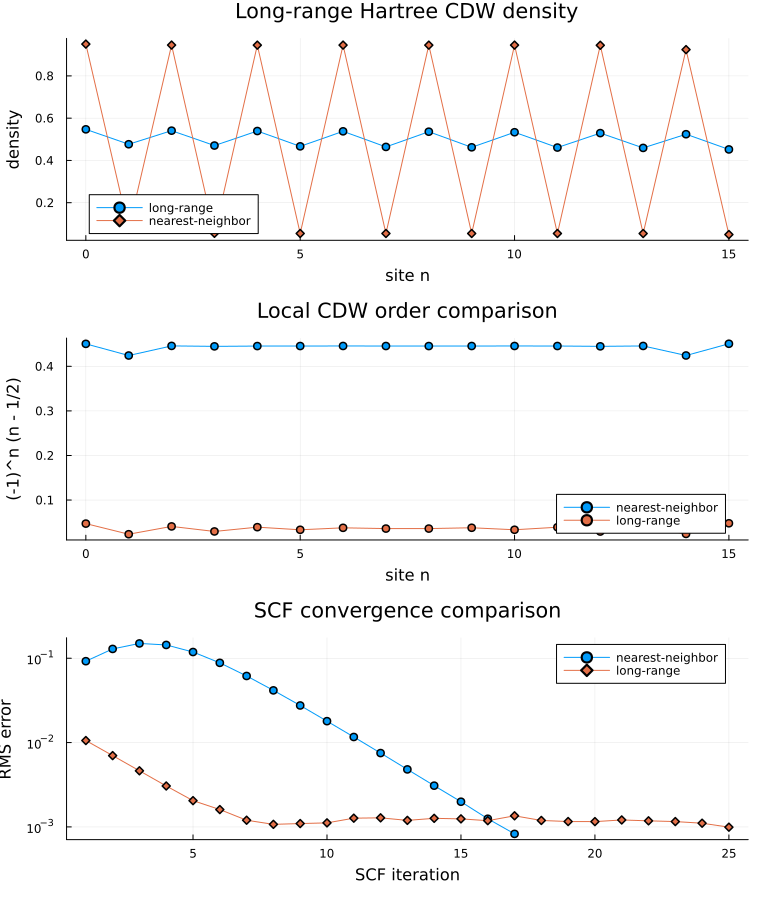

In [10]:
rho_long = [TensorBinding.scf_eval_profile_mps(result_long.density_mps, n) for n in 0:H0.N-1]
cdw_long = [(-1)^n * (rho_long[n + 1] - 0.5) for n in 0:H0.N-1]
hist_long_iter = [h.iter for h in result_long.history]
hist_long_rms = [h.rms_error for h in result_long.history]

p1 = plot(0:H0.N-1, rho_long;
          marker=:circle,
          xlabel="site n",
          ylabel="density",
          title="Long-range Hartree CDW density",
          label="long-range")
plot!(p1, 0:H0.N-1, rho_nn; marker=:diamond, label="nearest-neighbor")

p2 = plot(0:H0.N-1, [cdw_nn cdw_long];
          marker=:circle,
          xlabel="site n",
          ylabel="(-1)^n (n - 1/2)",
          title="Local CDW order comparison",
          label=["nearest-neighbor" "long-range"])

p3 = plot(hist_nn_iter, hist_nn_rms;
          yscale=:log10,
          marker=:circle,
          xlabel="SCF iteration",
          ylabel="RMS error",
          title="SCF convergence comparison",
          label="nearest-neighbor")
plot!(p3, hist_long_iter, hist_long_rms;
      yscale=:log10,
      marker=:diamond,
      label="long-range")

println("sum(rho_nn) - Nel = ", sum(rho_nn) - Nel)
println("sum(rho_long) - Nel = ", sum(rho_long) - Nel)
plot(p1, p2, p3; layout=(3, 1), size=(760, 900))

## 5. Other sparse fixed-distance interactions

The sparse builder also accepts multiple fixed distances. This is useful for finite-range models that are longer than nearest neighbor but still much sparser than a dense kernel.

In [ ]:
# Example: nearest and third-neighbor density-density interaction.
# sparse_builder = TensorBinding.scf_pair_distance_hartree_builder(
#     H0.L,
#     H0.sites,
#     [1 => 0.8, 3 => 0.3];
#     background=0.5,
#     maxdim=90,
#     cutoff=1e-8,
# )